# MMA 867 — Predicting Car Insurance Claim vs. No Claim
## *On the Road* — underwriting risk at quote time

**Dataset:** `car_insurance.csv` (10,000 customers × 18 variables)  
**Target:** `outcome` (1 = claim filed, 0 = no claim)  
**Approach:** Logistic regression baseline + tree-based benchmarks (Decision Tree, Random Forest, Gradient Boosting), feature-importance ranking, hypothesis testing, and a deployable risk-tier scoring function.


In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
np.random.seed(42)
print('Environment ready.')

Environment ready.


## 1. Load & First Look

In [2]:
df = pd.read_csv('car_insurance.csv')
print('Shape:', df.shape)
df.head()

Shape: (10000, 18)


,id,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,postal_code,annual_mileage,vehicle_type,speeding_violations,duis,past_accidents,outcome
0,569520,3,0,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,0,1,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,0,0,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,0,1,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,1,1,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   10000 non-null  int64  
 1   age                  10000 non-null  int64  
 2   gender               10000 non-null  int64  
 3   driving_experience   10000 non-null  str    
 4   education            10000 non-null  str    
 5   income               10000 non-null  str    
 6   credit_score         9018 non-null   float64
 7   vehicle_ownership    10000 non-null  float64
 8   vehicle_year         10000 non-null  str    
 9   married              10000 non-null  float64
 10  children             10000 non-null  float64
 11  postal_code          10000 non-null  int64  
 12  annual_mileage       9043 non-null   float64
 13  vehicle_type         10000 non-null  str    
 14  speeding_violations  10000 non-null  int64  
 15  duis                 10000 non-null  int64  
 16

In [4]:
# Target class balance
target_counts = df['outcome'].value_counts()
target_pct = df['outcome'].value_counts(normalize=True) * 100
print('Class balance:')
print(pd.DataFrame({'count': target_counts, 'pct': target_pct.round(2)}))

Class balance:
         count    pct
outcome              
0.0       6867  68.67
1.0       3133  31.33


## 2. Exploratory Data Analysis
Profile distributions, missingness, and relationships with the target.

In [5]:
# Missing values
miss = df.isna().sum()
miss_pct = (df.isna().mean()*100).round(2)
miss_table = pd.DataFrame({'missing': miss, 'pct': miss_pct})
miss_table[miss_table['missing'] > 0]

,missing,pct
credit_score,982,9.82
annual_mileage,957,9.57


In [6]:
# Numeric summary
df.describe()

,id,age,gender,credit_score,vehicle_ownership,married,children,postal_code,annual_mileage,speeding_violations,duis,past_accidents,outcome
count,10000.000000,10000.000000,10000.000000,9018.000000,10000.000000,10000.000000,10000.000000,10000.000000,9043.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,500521.906800,1.489500,0.499000,0.515813,0.697000,0.498200,0.688800,19864.548400,11697.003207,1.482900,0.23920,1.056300,0.313300
std,290030.768758,1.025278,0.500024,0.137688,0.459578,0.500022,0.463008,18915.613855,2818.434528,2.241966,0.55499,1.652454,0.463858
min,101.000000,0.000000,0.000000,0.053358,0.000000,0.000000,0.000000,10238.000000,2000.000000,0.000000,0.00000,0.000000,0.000000
25%,249638.500000,1.000000,0.000000,0.417191,0.000000,0.000000,0.000000,10238.000000,10000.000000,0.000000,0.00000,0.000000,0.000000
50%,501777.000000,1.000000,0.000000,0.525033,1.000000,0.000000,1.000000,10238.000000,12000.000000,0.000000,0.00000,0.000000,0.000000
75%,753974.500000,2.000000,1.000000,0.618312,1.000000,1.000000,1.000000,32765.000000,14000.000000,2.000000,0.00000,2.000000,1.000000
max,999976.000000,3.000000,1.000000,0.960819,1.000000,1.000000,1.000000,92101.000000,22000.000000,22.000000,6.00000,15.000000,1.000000


In [7]:
# Categorical summary
df.select_dtypes(include='object').describe()

,driving_experience,education,income,vehicle_year,vehicle_type
count,10000,10000,10000,10000,10000
unique,4,3,4,2,2
top,0-9y,high school,upper class,before 2015,sedan
freq,3530,4157,4336,6967,9523


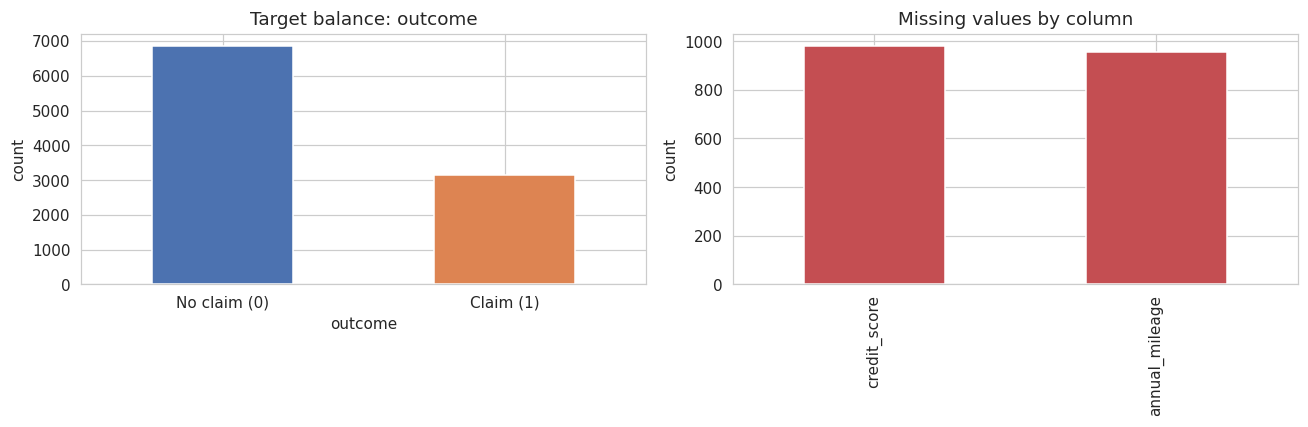

In [8]:
# Visualise target balance + missingness
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['outcome'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Target balance: outcome')
axes[0].set_xticklabels(['No claim (0)', 'Claim (1)'], rotation=0)
axes[0].set_ylabel('count')

miss_table[miss_table['missing']>0]['missing'].plot(kind='bar', ax=axes[1], color='#C44E52')
axes[1].set_title('Missing values by column')
axes[1].set_ylabel('count')
plt.tight_layout(); plt.show()

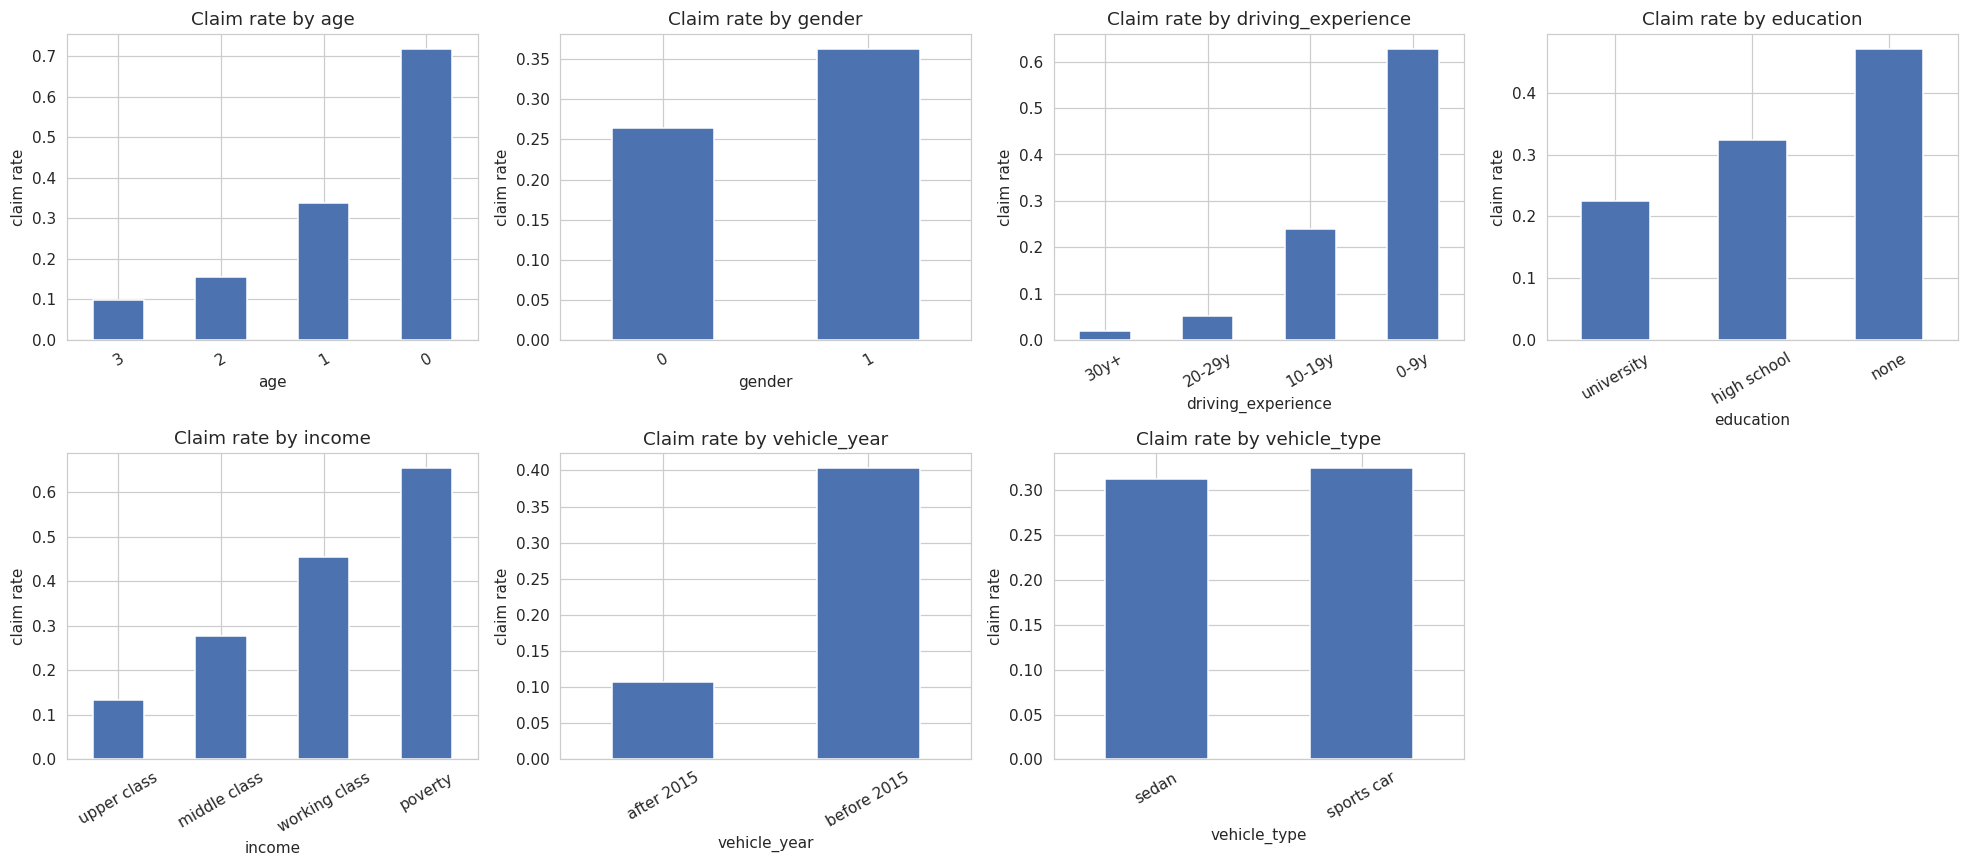

In [9]:
# Claim rate by key categorical drivers
cat_drivers = ['age', 'gender', 'driving_experience', 'education',
               'income', 'vehicle_year', 'vehicle_type']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(cat_drivers):
    rate = df.groupby(col)['outcome'].mean().sort_values()
    rate.plot(kind='bar', ax=axes[i], color='#4C72B0')
    axes[i].set_title(f'Claim rate by {col}')
    axes[i].set_ylabel('claim rate')
    axes[i].tick_params(axis='x', rotation=30)
axes[-1].axis('off')
plt.tight_layout(); plt.show()

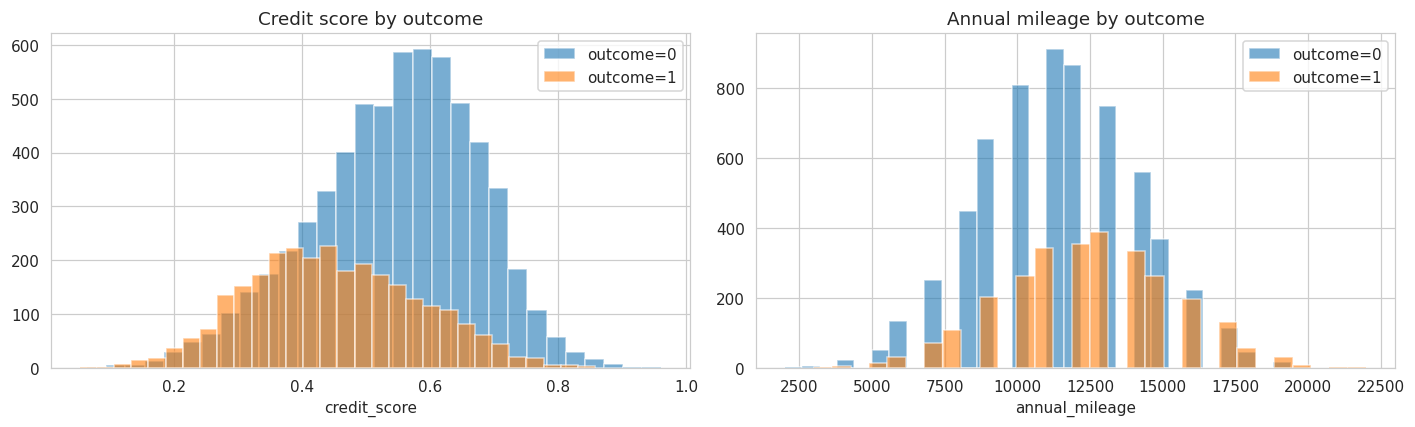

In [10]:
# Numeric drivers: credit_score & annual_mileage by outcome
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for label, sub in df.groupby('outcome'):
    sub['credit_score'].hist(bins=30, alpha=0.6, ax=axes[0],
                             label=f'outcome={int(label)}')
axes[0].set_title('Credit score by outcome'); axes[0].set_xlabel('credit_score'); axes[0].legend()

for label, sub in df.groupby('outcome'):
    sub['annual_mileage'].hist(bins=30, alpha=0.6, ax=axes[1],
                               label=f'outcome={int(label)}')
axes[1].set_title('Annual mileage by outcome'); axes[1].set_xlabel('annual_mileage'); axes[1].legend()
plt.tight_layout(); plt.show()

## 3. Cleaning & Missing-Value Treatment
Two columns have missing values: `credit_score` (~10%) and `annual_mileage` (~10%).

Per the proposal:
- **credit_score**: median-impute *and* add a `credit_score_missing` flag so the model can learn the distinct risk profile of customers without credit history.
- **annual_mileage**: median-impute (no flag — assumed missing at random).


In [11]:
df_clean = df.copy()

# credit_score: flag + median impute
df_clean['credit_score_missing'] = df_clean['credit_score'].isna().astype(int)
df_clean['credit_score'] = df_clean['credit_score'].fillna(df_clean['credit_score'].median())

# annual_mileage: median impute
df_clean['annual_mileage'] = df_clean['annual_mileage'].fillna(df_clean['annual_mileage'].median())

print('Missing after cleaning:', df_clean.isna().sum().sum())
df_clean.head()

Missing after cleaning: 0


,id,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,postal_code,annual_mileage,vehicle_type,speeding_violations,duis,past_accidents,outcome,credit_score_missing
0,569520,3,0,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0,0
1,750365,0,1,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0,0
2,199901,0,0,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0,0
3,478866,0,1,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0,0
4,731664,1,1,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0,0


## 4. Feature Engineering

- **Ordinal encoding** for naturally ordered variables: `driving_experience`, `education`, `income`. (`age` is already ordinal 0–3.)
- **One-hot encoding** for unordered categoricals: `vehicle_year`, `vehicle_type`.
- Drop `id` and `postal_code` (identifiers; postal_code is high-cardinality and not a clean signal).

In [12]:
df_fe = df_clean.copy()

# Ordinal maps
driving_exp_map = {'0-9y': 0, '10-19y': 1, '20-29y': 2, '30y+': 3}
education_map   = {'none': 0, 'high school': 1, 'university': 2}
income_map      = {'poverty': 0, 'working class': 1, 'middle class': 2, 'upper class': 3}

df_fe['driving_experience'] = df_fe['driving_experience'].map(driving_exp_map)
df_fe['education']          = df_fe['education'].map(education_map)
df_fe['income']             = df_fe['income'].map(income_map)

# One-hot for unordered categoricals
df_fe = pd.get_dummies(df_fe, columns=['vehicle_year', 'vehicle_type'], drop_first=True)

# Drop identifiers
df_fe = df_fe.drop(columns=['id', 'postal_code'])

# Cast booleans to int for clean coefficients
for c in df_fe.select_dtypes(include='bool').columns:
    df_fe[c] = df_fe[c].astype(int)

print('Final feature set shape:', df_fe.shape)
df_fe.head()

Final feature set shape: (10000, 17)


,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,married,children,annual_mileage,speeding_violations,duis,past_accidents,outcome,credit_score_missing,vehicle_year_before 2015,vehicle_type_sports car
0,3,0,0,1,3,0.629027,1.0,0.0,1.0,12000.0,0,0,0,0.0,0,0,0
1,0,1,0,0,0,0.357757,0.0,0.0,0.0,16000.0,0,0,0,1.0,0,1,0
2,0,0,0,1,1,0.493146,1.0,0.0,0.0,11000.0,0,0,0,0.0,0,1,0
3,0,1,0,2,1,0.206013,1.0,0.0,1.0,11000.0,0,0,0,0.0,0,1,0
4,1,1,1,0,1,0.388366,1.0,0.0,0.0,12000.0,2,0,1,1.0,0,1,0


## 5. Train / Test Split

In [13]:
y = df_fe['outcome'].astype(int)
X = df_fe.drop(columns=['outcome'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Train claim rate:', y_train.mean().round(3),
      '  Test claim rate:', y_test.mean().round(3))

Train: (8000, 16)  Test: (2000, 16)
Train claim rate: 0.313   Test claim rate: 0.314


## 6. Hypothesis Testing
Before modelling we validate the proposal's assumptions about which drivers matter.

- **Chi-square** for categorical / ordinal features vs. outcome.
- **Welch's t-test** for continuous features (credit_score, annual_mileage) across claim / no-claim groups.

H₀: feature is independent of (or equal across) claim outcome.

In [14]:
# Chi-square on categorical / ordinal predictors
chi_cols = ['age', 'gender', 'driving_experience', 'education', 'income',
            'vehicle_ownership', 'married', 'children', 'credit_score_missing']
chi_rows = []
for c in chi_cols:
    ct = pd.crosstab(df_fe[c], df_fe['outcome'])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    chi_rows.append({'feature': c, 'chi2': round(chi2, 2),
                     'dof': dof, 'p_value': p,
                     'reject_H0_at_0.05': p < 0.05})
chi_df = pd.DataFrame(chi_rows).sort_values('chi2', ascending=False)
chi_df

,feature,chi2,dof,p_value,reject_H0_at_0.05
2,driving_experience,2809.94,3,0.000000e+00,True
0,age,2308.83,3,0.000000e+00,True
4,income,1797.96,3,0.000000e+00,True
5,vehicle_ownership,1434.04,1,0.000000e+00,True
6,married,685.85,1,3.564358e-151,True
7,children,541.04,1,1.120241e-119,True
3,education,365.37,2,4.577462e-80,True
1,gender,114.47,1,1.026508e-26,True
8,credit_score_missing,0.05,1,8.188855e-01,False


In [15]:
# Welch's t-test for continuous features
t_rows = []
for c in ['credit_score', 'annual_mileage', 'speeding_violations', 'duis', 'past_accidents']:
    g0 = df_fe.loc[df_fe['outcome']==0, c]
    g1 = df_fe.loc[df_fe['outcome']==1, c]
    t, p = stats.ttest_ind(g0, g1, equal_var=False)
    t_rows.append({'feature': c, 'mean_no_claim': round(g0.mean(),3),
                   'mean_claim': round(g1.mean(),3),
                   't_stat': round(t,2), 'p_value': p,
                   'reject_H0_at_0.05': p < 0.05})
t_df = pd.DataFrame(t_rows).sort_values('t_stat', key=abs, ascending=False)
t_df

,feature,mean_no_claim,mean_claim,t_stat,p_value,reject_H0_at_0.05
4,past_accidents,1.404,0.294,42.33,0.000000e+00,True
2,speeding_violations,1.925,0.514,37.70,1.649129e-290,True
0,credit_score,0.544,0.457,31.90,6.881508e-206,True
3,duis,0.310,0.084,23.66,2.500550e-120,True
1,annual_mileage,11403.524,12432.812,-17.68,3.434403e-68,True


## 7. Baseline Logistic Regression
Standardised features, L2-regularised logistic regression. Standardisation lets us read coefficient magnitudes as comparable importance signals.

In [16]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

logit = LogisticRegression(max_iter=2000, random_state=42)
logit.fit(X_train_s, y_train)

y_pred_lr  = logit.predict(X_test_s)
y_proba_lr = logit.predict_proba(X_test_s)[:, 1]

print('Logistic Regression — Test set')
print(f'  Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred_lr):.4f}')
print(f'  Recall   : {recall_score(y_test, y_pred_lr):.4f}')
print(f'  F1       : {f1_score(y_test, y_pred_lr):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, y_proba_lr):.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['No Claim','Claim']))

Logistic Regression — Test set
  Accuracy : 0.8305
  Precision: 0.7315
  Recall   : 0.7257
  F1       : 0.7286
  ROC-AUC  : 0.8865

              precision    recall  f1-score   support

    No Claim       0.88      0.88      0.88      1373
       Claim       0.73      0.73      0.73       627

    accuracy                           0.83      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.83      0.83      0.83      2000



In [17]:
# Logistic regression coefficient table
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef': logit.coef_[0],
    'abs_coef': np.abs(logit.coef_[0]),
    'odds_ratio': np.exp(logit.coef_[0])
}).sort_values('abs_coef', ascending=False)
coef_df.reset_index(drop=True)

,feature,coef,abs_coef,odds_ratio
0,driving_experience,-1.687005,1.687005,0.185073
1,vehicle_year_before 2015,0.776008,0.776008,2.172781
2,vehicle_ownership,-0.770485,0.770485,0.462788
3,gender,0.454604,0.454604,1.575550
4,past_accidents,-0.370333,0.370333,0.690505
5,speeding_violations,0.188469,0.188469,1.207399
6,married,-0.188255,0.188255,0.828403
7,annual_mileage,0.112192,0.112192,1.118727
8,children,-0.100275,0.100275,0.904589
9,duis,0.068116,0.068116,1.070490


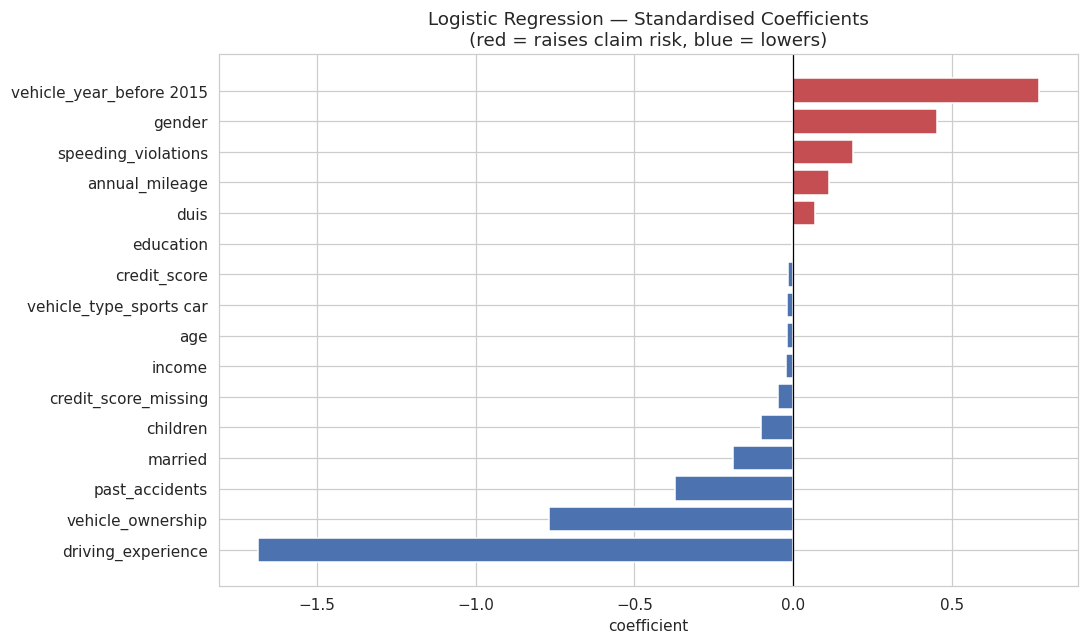

In [18]:
# Visualise coefficients
plt.figure(figsize=(10, 6))
plot_df = coef_df.sort_values('coef')
colors = ['#C44E52' if v>0 else '#4C72B0' for v in plot_df['coef']]
plt.barh(plot_df['feature'], plot_df['coef'], color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.title('Logistic Regression — Standardised Coefficients\n(red = raises claim risk, blue = lowers)')
plt.xlabel('coefficient'); plt.tight_layout(); plt.show()

## 8. Tree-Based Benchmarks
Compare logistic regression to Decision Tree, Random Forest, and Gradient Boosting.

In [19]:
models = {
    'Logistic Regression': logit,
    'Decision Tree'      : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=300, max_depth=10,
                                                  random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                                      learning_rate=0.05, random_state=42),
}

results = []
fitted = {}
for name, mdl in models.items():
    if name == 'Logistic Regression':
        Xtr, Xte = X_train_s, X_test_s
    else:
        Xtr, Xte = X_train, X_test
        mdl.fit(Xtr, y_train)
    fitted[name] = mdl
    y_pred  = mdl.predict(Xte)
    y_proba = mdl.predict_proba(Xte)[:, 1]
    results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1'       : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.8305,0.7315,0.7257,0.7286,0.8865
Decision Tree,0.8250,0.7259,0.7097,0.7177,0.8729
Random Forest,0.8245,0.7262,0.7065,0.7162,0.8762
Gradient Boosting,0.8295,0.7306,0.7225,0.7265,0.8814


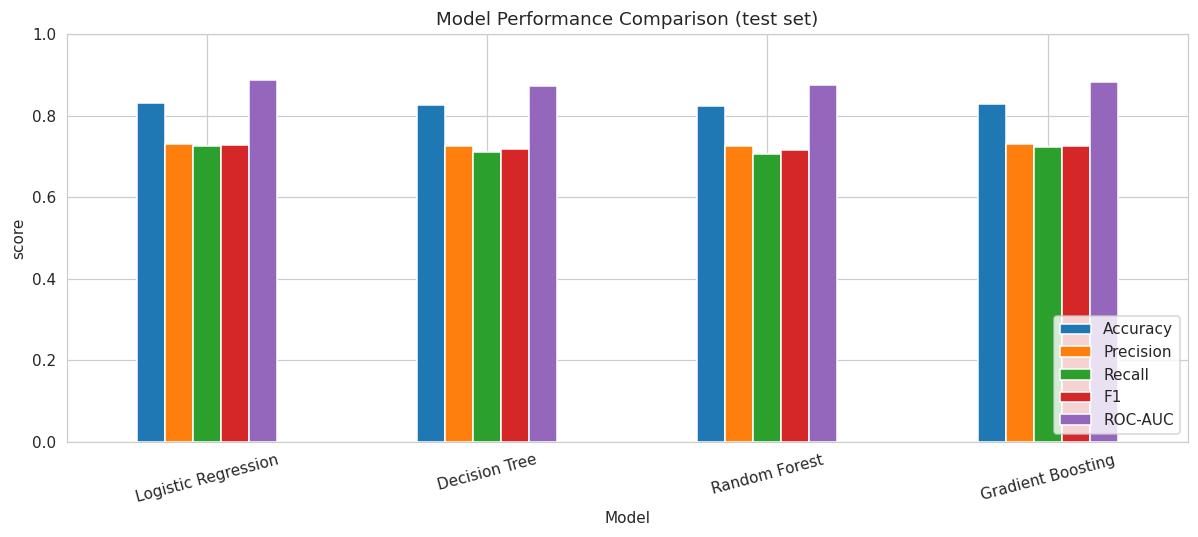

In [20]:
# Visual comparison
results_df[['Accuracy','Precision','Recall','F1','ROC-AUC']].plot(
    kind='bar', figsize=(11, 5))
plt.title('Model Performance Comparison (test set)')
plt.ylabel('score'); plt.ylim(0, 1)
plt.legend(loc='lower right'); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

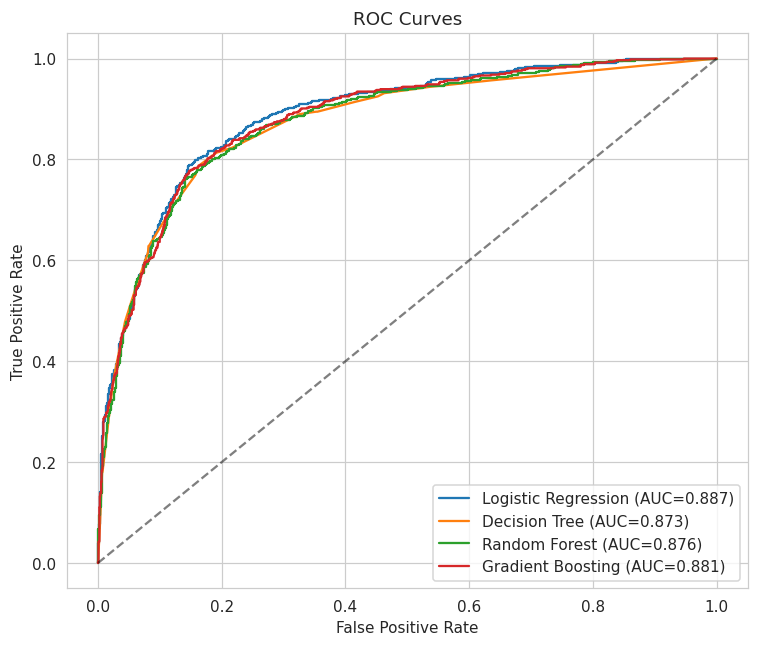

In [21]:
# ROC curves
plt.figure(figsize=(7, 6))
for name, mdl in fitted.items():
    Xte = X_test_s if name == 'Logistic Regression' else X_test
    y_proba = mdl.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves'); plt.legend()
plt.tight_layout(); plt.show()

Best model by ROC-AUC: Logistic Regression


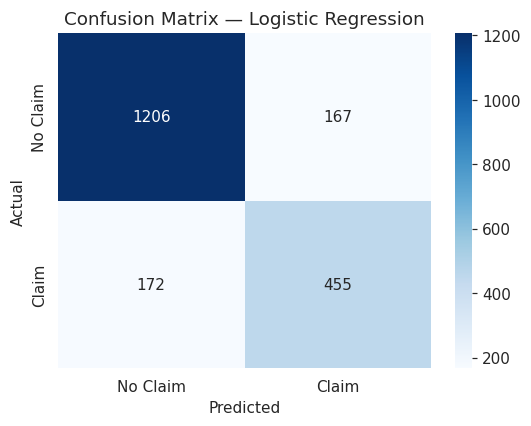

In [22]:
# Confusion matrix of the best model (by ROC-AUC)
best_name = results_df['ROC-AUC'].idxmax()
print('Best model by ROC-AUC:', best_name)
Xte = X_test_s if best_name == 'Logistic Regression' else X_test
best_mdl = fitted[best_name]
cm = confusion_matrix(y_test, best_mdl.predict(Xte))

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Claim','Claim'],
            yticklabels=['No Claim','Claim'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

## 9. Feature Importance Ranking
Use Random Forest's impurity-based importances as the headline ranking, and cross-check against Gradient Boosting and the standardised logistic coefficients.

In [23]:
rf = fitted['Random Forest']
gb = fitted['Gradient Boosting']

imp_df = pd.DataFrame({
    'feature': X.columns,
    'RF_importance': rf.feature_importances_,
    'GB_importance': gb.feature_importances_,
    'LR_abs_coef':   np.abs(logit.coef_[0]),
}).sort_values('RF_importance', ascending=False).reset_index(drop=True)
imp_df

,feature,RF_importance,GB_importance,LR_abs_coef
0,driving_experience,0.212859,0.552236,1.687005
1,vehicle_ownership,0.121906,0.155815,0.770485
2,age,0.113993,0.021314,0.019196
3,credit_score,0.089850,0.024849,0.015893
4,vehicle_year_before 2015,0.086545,0.145527,0.776008
5,income,0.073559,0.017834,0.020912
6,speeding_violations,0.069606,0.003244,0.188469
7,past_accidents,0.064344,0.009154,0.370333
8,annual_mileage,0.053937,0.013098,0.112192
9,gender,0.034780,0.037294,0.454604


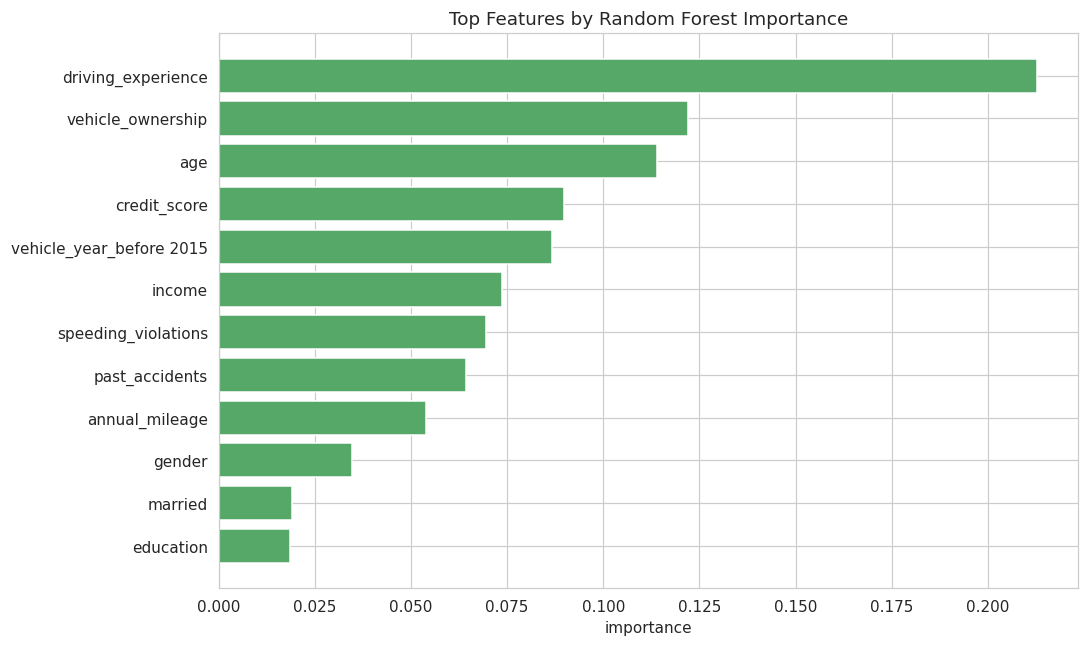

In [24]:
plt.figure(figsize=(10, 6))
top = imp_df.sort_values('RF_importance').tail(12)
plt.barh(top['feature'], top['RF_importance'], color='#55A868')
plt.title('Top Features by Random Forest Importance')
plt.xlabel('importance'); plt.tight_layout(); plt.show()

## 10. Streamlined Model on Top Features
Per the proposal: benchmark a parsimonious model on top features vs. the full multivariate model — this informs which intake-form questions are worth asking.

In [25]:
top_k = 6
top_feats = imp_df['feature'].head(top_k).tolist()
print('Top', top_k, 'features:', top_feats)

X_top = X[top_feats]
Xtr_top, Xte_top, ytr_top, yte_top = train_test_split(
    X_top, y, test_size=0.2, random_state=42, stratify=y)

# Logistic on top features
scaler_top = StandardScaler()
Xtr_top_s = scaler_top.fit_transform(Xtr_top)
Xte_top_s = scaler_top.transform(Xte_top)

lr_top = LogisticRegression(max_iter=2000, random_state=42)
lr_top.fit(Xtr_top_s, ytr_top)
y_pred_top  = lr_top.predict(Xte_top_s)
y_proba_top = lr_top.predict_proba(Xte_top_s)[:, 1]

print(f'\nStreamlined Logistic Regression ({top_k} features)')
print(f'  Accuracy: {accuracy_score(yte_top, y_pred_top):.4f}')
print(f'  ROC-AUC : {roc_auc_score(yte_top, y_proba_top):.4f}')

print(f'\nFull Logistic Regression ({X.shape[1]} features)')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'  ROC-AUC : {roc_auc_score(y_test, y_proba_lr):.4f}')

Top 6 features: ['driving_experience', 'vehicle_ownership', 'age', 'credit_score', 'vehicle_year_before 2015', 'income']

Streamlined Logistic Regression (6 features)
  Accuracy: 0.8115
  ROC-AUC : 0.8678

Full Logistic Regression (16 features)
  Accuracy: 0.8305
  ROC-AUC : 0.8865


## 11. Single-Best-Feature Model
The DataCamp brief asks for the single feature giving the best accuracy — useful as the *minimum viable* model the client could deploy with zero ML infra.

In [26]:
single_results = []
for col in X.columns:
    mdl = LogisticRegression(max_iter=1000, random_state=42)
    mdl.fit(X_train[[col]], y_train)
    acc = accuracy_score(y_test, mdl.predict(X_test[[col]]))
    single_results.append({'feature': col, 'accuracy': acc})

single_df = pd.DataFrame(single_results).sort_values('accuracy', ascending=False).reset_index(drop=True)
print('Top 5 single-feature models:')
single_df.head()

Top 5 single-feature models:


,feature,accuracy
0,age,0.7720
1,driving_experience,0.7650
2,income,0.7380
3,vehicle_ownership,0.7270
4,credit_score,0.6975


## 12. Deployable Underwriting Scoring Function
End-to-end: customer record → claim probability → risk tier. This is what gets wired up to the Google Form intake.

In [27]:
def score_customer(record: dict, model=logit, scaler=scaler,
                   feature_order=list(X.columns),
                   driving_exp_map=driving_exp_map,
                   education_map=education_map,
                   income_map=income_map):
    """
    Take a raw customer record (as it would come off the intake form),
    return claim probability and a risk tier.

    Expected keys (raw):
      age, gender, driving_experience, education, income, credit_score,
      vehicle_ownership, vehicle_year, married, children, annual_mileage,
      vehicle_type, speeding_violations, duis, past_accidents
    credit_score may be None / NaN.
    """
    r = dict(record)

    # Ordinal encoding
    if isinstance(r.get('driving_experience'), str):
        r['driving_experience'] = driving_exp_map[r['driving_experience']]
    if isinstance(r.get('education'), str):
        r['education'] = education_map[r['education']]
    if isinstance(r.get('income'), str):
        r['income'] = income_map[r['income']]

    # credit_score: flag + median impute (use training median)
    cs = r.get('credit_score')
    if cs is None or (isinstance(cs, float) and np.isnan(cs)):
        r['credit_score_missing'] = 1
        r['credit_score'] = df_clean['credit_score'].median()
    else:
        r['credit_score_missing'] = 0

    # annual_mileage: median impute if missing
    am = r.get('annual_mileage')
    if am is None or (isinstance(am, float) and np.isnan(am)):
        r['annual_mileage'] = df_clean['annual_mileage'].median()

    # One-hot encodings for vehicle_year and vehicle_type
    r['vehicle_year_before 2015'] = 1 if r.get('vehicle_year') == 'before 2015' else 0
    r['vehicle_type_sports car']  = 1 if r.get('vehicle_type')  == 'sports car'  else 0

    # Build the feature vector in the trained order
    row = [r.get(f, 0) for f in feature_order]
    row = np.array(row, dtype=float).reshape(1, -1)
    row_s = scaler.transform(row)

    prob = float(model.predict_proba(row_s)[0, 1])

    # Risk tier — equal-width thresholds; tune on business loss data
    if   prob < 0.25: tier = 'Low'
    elif prob < 0.50: tier = 'Medium'
    elif prob < 0.75: tier = 'High'
    else:             tier = 'Very High'

    return {'claim_probability': round(prob, 4),
            'risk_tier': tier,
            'recommend_claim_label': int(prob >= 0.5)}

# Demo on 3 fictional applicants
demo_applicants = [
    {  # Profile A: experienced, owns car, good credit
        'age': 2, 'gender': 1, 'driving_experience': '20-29y',
        'education': 'university', 'income': 'upper class',
        'credit_score': 0.78, 'vehicle_ownership': 1.0,
        'vehicle_year': 'after 2015', 'married': 1.0, 'children': 1.0,
        'annual_mileage': 10000, 'vehicle_type': 'sedan',
        'speeding_violations': 0, 'duis': 0, 'past_accidents': 0,
    },
    {  # Profile B: young, inexperienced, missing credit, sports car
        'age': 0, 'gender': 1, 'driving_experience': '0-9y',
        'education': 'high school', 'income': 'working class',
        'credit_score': None, 'vehicle_ownership': 0.0,
        'vehicle_year': 'before 2015', 'married': 0.0, 'children': 0.0,
        'annual_mileage': 18000, 'vehicle_type': 'sports car',
        'speeding_violations': 3, 'duis': 1, 'past_accidents': 2,
    },
    {  # Profile C: middle-aged, average everything
        'age': 1, 'gender': 0, 'driving_experience': '10-19y',
        'education': 'high school', 'income': 'middle class',
        'credit_score': 0.55, 'vehicle_ownership': 1.0,
        'vehicle_year': 'before 2015', 'married': 1.0, 'children': 2.0,
        'annual_mileage': 12000, 'vehicle_type': 'sedan',
        'speeding_violations': 1, 'duis': 0, 'past_accidents': 0,
    },
]

for i, a in enumerate(demo_applicants, 1):
    out = score_customer(a)
    print(f'Applicant {i}: {out}')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
Applicant 1: {'claim_probability': 0.0085, 'risk_tier': 'Low', 'recommend_claim_label': 0}
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
Applicant 2: {'claim_probability': 0.9391, 'risk_tier': 'Very High', 'recommend_claim_label': 1}
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
Applicant 3: {'claim_probability': 0.0953, 'risk_tier': 'Low', 'recommend_claim_label': 0}


## 13. Summary

**Pipeline delivered**
1. Loaded 10,000 customer records, profiled 18 variables, surfaced ~10% missingness in `credit_score` and `annual_mileage`.
2. Cleaned with median imputation; added the `credit_score_missing` flag to preserve the no-credit-history risk signal.
3. Engineered features with ordinal encoding (income, education, driving_experience) and one-hot encoding (vehicle_year, vehicle_type).
4. Validated assumptions with chi-square and Welch's t-tests.
5. Trained logistic regression baseline + Decision Tree, Random Forest, and Gradient Boosting benchmarks.
6. Ranked features by RF importance, cross-checked with GB and standardised logistic coefficients.
7. Compared a streamlined top-6 model against the full multivariate model.
8. Reported the single-best-feature accuracy for the DataCamp deliverable.
9. Wrapped the model in a `score_customer()` function returning probability + risk tier — deployable as-is behind the Google Form intake.